In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df =pd.read_csv("StudentsPerformance.csv")
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [6]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

In [14]:
df.rename(columns ={
    'race/ethnicity':'race',
     'parental level of education':'parental_education',
      'test preparation course':'test_preparation_course',
      'math score': 'math_score', 
        'reading score': 'reading_score',
        'writing score': 'writing_score',
    }, inplace=True
)

In [10]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


Average score in Math : 66.089
Average score in Reading : 69.169
Average score in Writing : 68.054




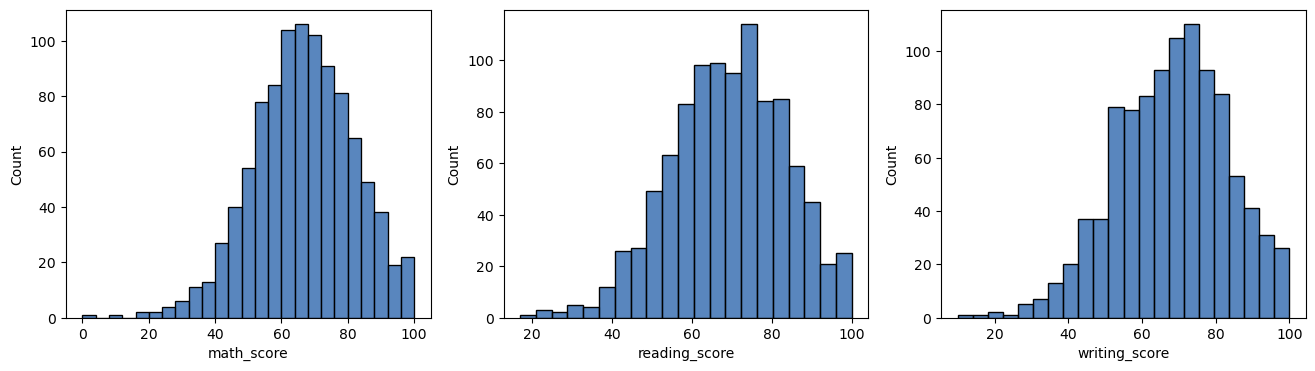

In [16]:
fig, ax = plt.subplots(1, 3, figsize = (16, 4))

#ax
sns.histplot(x = 'math_score', data = df, ax = ax[0], color = '#225ea8')
sns.histplot(x = 'reading_score', data = df, ax = ax[1], color = '#225ea8')
sns.histplot(x = 'writing_score', data = df, ax = ax[2], color = '#225ea8')


math_mean = df['math_score'].mean()
reading_mean = df['reading_score'].mean()
writing_mean = df['writing_score'].mean()

print(f'Average score in Math : { math_mean }\nAverage score in Reading : { reading_mean }\nAverage score in Writing : { writing_mean }\n\n')
plt.show()

In [22]:
pass_grade = 50

df['pass_math'] = 'yes'
filt = (df['math_score'] < pass_grade)
df.loc[filt,'pass_math'] = 'no'
df[['math_score', 'pass_math']].head()

df['pass_reading'] = 'yes'
filt = (df['reading_score'] < pass_grade)
df.loc[filt,'pass_reading'] = 'no'
df[['reading_score', 'pass_reading']].head()

df['pass_writing'] = 'yes'
filt = (df['writing_score'] < pass_grade)
df.loc[filt,'pass_writing'] = 'no'
df[['writing_score', 'pass_writing']].head()

df

,gender,race,parental_education,lunch,test_preparation_course,math_score,reading_score,writing_score,pass_math,pass_reading,pass_writing
0,female,group B,bachelor's degree,standard,none,72,72,74,yes,yes,yes
1,female,group C,some college,standard,completed,69,90,88,yes,yes,yes
2,female,group B,master's degree,standard,none,90,95,93,yes,yes,yes
3,male,group A,associate's degree,free/reduced,none,47,57,44,no,yes,no
4,male,group C,some college,standard,none,76,78,75,yes,yes,yes
...,...,...,...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95,yes,yes,yes
996,male,group C,high school,free/reduced,none,62,55,55,yes,yes,yes
997,female,group C,high school,free/reduced,completed,59,71,65,yes,yes,yes
998,female,group D,some college,standard,completed,68,78,77,yes,yes,yes


pass_math
no     135
yes    865
Name: pass_math, dtype: int64
pass_reading
no      90
yes    910
Name: pass_reading, dtype: int64
pass_writing
no     114
yes    886
Name: pass_writing, dtype: int64


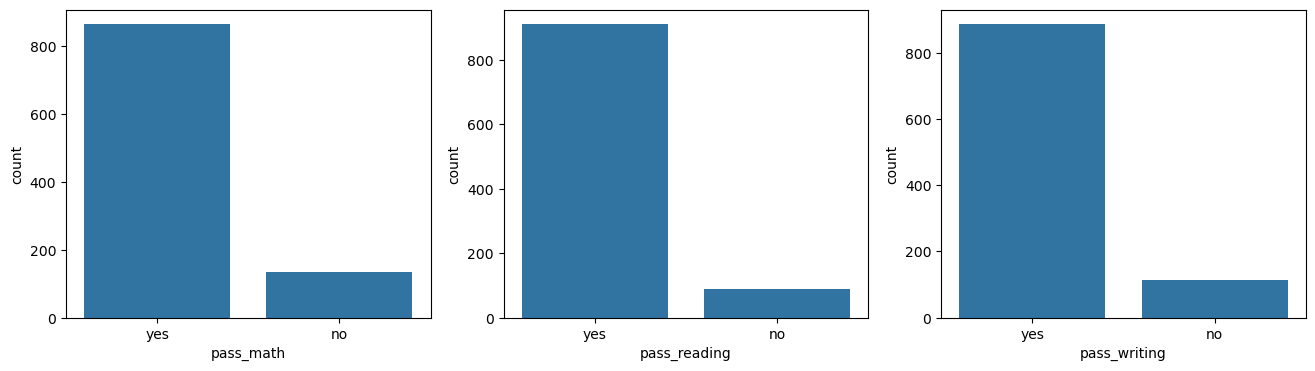

In [23]:
fig, ax = plt.subplots(1, 3, figsize = (16, 4))

sns.countplot(x = 'pass_math', data = df, ax = ax[0])
sns.countplot(x = 'pass_reading', data = df, ax = ax[1])
sns.countplot(x = 'pass_writing', data = df, ax = ax[2])

pass_math_count = df.groupby('pass_math')['pass_math'].count()
print(pass_math_count)
pass_math_count = df.groupby('pass_reading')['pass_reading'].count()
print(pass_math_count)
pass_math_count = df.groupby('pass_writing')['pass_writing'].count()
print(pass_math_count)

plt.show()

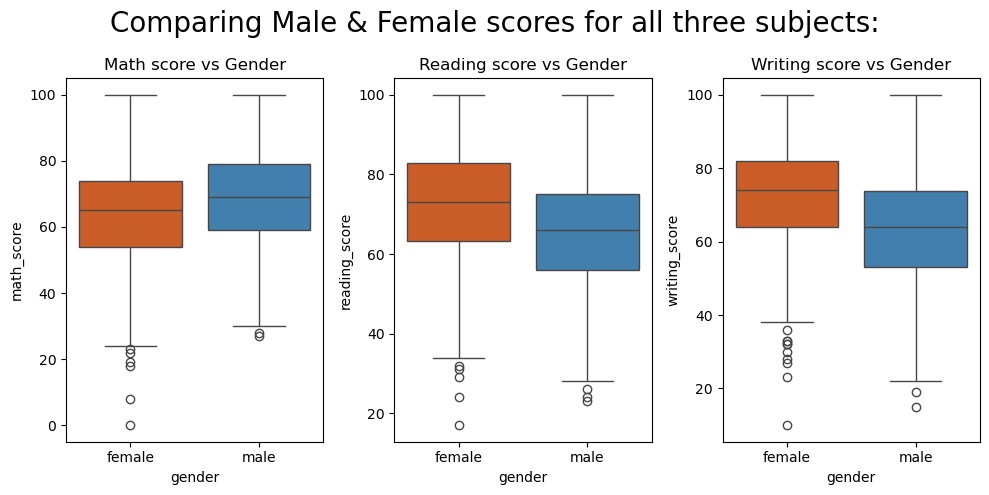

In [28]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(10, 5))
fig.suptitle('Comparing Male & Female scores for all three subjects:', fontsize=20)

colors = {'male': '#3182bd', 'female': '#e6550d'}  

# Math score
sns.boxplot(x='gender', y='math_score', data=df, ax=ax1, hue='gender', palette=colors, legend=False)
ax1.title.set_text('Math score vs Gender')

# Reading Score
sns.boxplot(x='gender', y='reading_score', data=df, ax=ax2, hue='gender', palette=colors, legend=False)
ax2.title.set_text('Reading score vs Gender')

# Writing Score
sns.boxplot(x='gender', y='writing_score', data=df, ax=ax3, hue='gender', palette=colors, legend=False)
ax3.title.set_text('Writing score vs Gender')

plt.tight_layout()
plt.show()